In [1]:
# ---------------- Import Libraries ----------------
import numpy as np  # for numerical operations
import pandas as pd  # for data handling
import matplotlib.pyplot as plt  # for plotting
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ---------------- Load Dataset ----------------
dataset = pd.read_csv('Wine.csv')  # load dataset
X = dataset.iloc[:, 0:13].values  # independent variables (features)
y = dataset.iloc[:, 13].values  # target variable

In [3]:
# ---------------- Train-Test Split ----------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)  # split data

In [4]:
# ---------------- Feature Scaling ----------------
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)  # scale training data
X_test = sc.transform(X_test)  # scale test data

In [5]:
# ---------------- PCA ----------------
from sklearn.decomposition import PCA
pca = PCA(n_components=2)  # reduce to 2 principal components for visualization
X_train = pca.fit_transform(X_train)  # apply PCA on training data
X_test = pca.transform(X_test)  # apply PCA on test data
explained_variance = pca.explained_variance_ratio_  # check how much info each PC captures

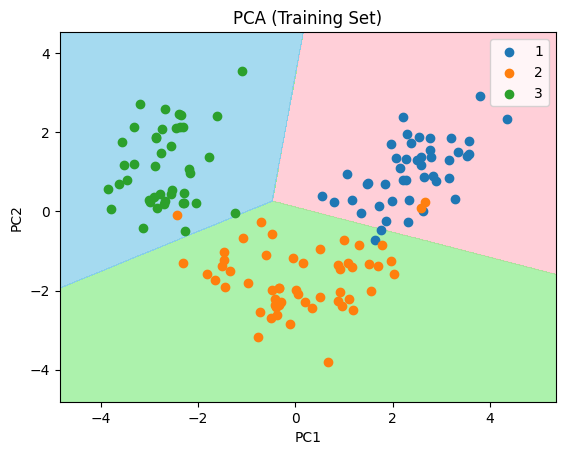

In [7]:
# ---------------- Visualization (Training Set) ----------------
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train  # use PCA transformed data

X1, X2 = np.meshgrid(np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
                     np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01))  # create grid

from sklearn.linear_model import LogisticRegression
temp_model = LogisticRegression(max_iter=1000)
temp_model.fit(X_train, y_train)  # temporary model for plotting

plt.contourf(X1, X2, temp_model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('pink','lightgreen','skyblue')))  # decision boundary

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set==j,0], X_set[y_set==j,1], label=j)  # plot points

plt.title('PCA (Training Set)')  # title
plt.xlabel('PC1')  # x-axis
plt.ylabel('PC2')  # y-axis
plt.legend()
plt.show()

After applying PCA, the data is clearly separated into three groups, showing that PC1 and PC2 capture the key patterns and make classification easier for the model.

In [8]:
# ---------------- Model Evaluation Function ----------------
from sklearn.metrics import accuracy_score

def model_accuracy(model, X_train, y_train, X_test, y_test):  # train and evaluate model
    model.fit(X_train, y_train)  # train model
    y_pred = model.predict(X_test)  # predict test data
    return accuracy_score(y_test, y_pred)  # return accuracy

In [10]:
# ---------------- Models ----------------
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# store results
acclog=[]; accsvml=[]; accsvmnl=[]; accknn=[]; accnav=[]; accdes=[]; accrf=[]

# run models
acclog.append(model_accuracy(LogisticRegression(max_iter=1000), X_train, y_train, X_test, y_test))  # logistic
accsvml.append(model_accuracy(SVC(kernel='linear'), X_train, y_train, X_test, y_test))  # svm linear
accsvmnl.append(model_accuracy(SVC(kernel='rbf'), X_train, y_train, X_test, y_test))  # svm nonlinear
accknn.append(model_accuracy(KNeighborsClassifier(n_neighbors=5), X_train, y_train, X_test, y_test))  # knn
accnav.append(model_accuracy(GaussianNB(), X_train, y_train, X_test, y_test))  # naive bayes
accdes.append(model_accuracy(DecisionTreeClassifier(), X_train, y_train, X_test, y_test))  # decision tree
accrf.append(model_accuracy(RandomForestClassifier(n_estimators=100), X_train, y_train, X_test, y_test))  # random forest

In [11]:
# ---------------- Result Table ----------------
result = pd.DataFrame(index=['PCA'], columns=['Logistic','SVMl','SVMnl','KNN','Navie','Decision','Random'])  # create table

result.loc['PCA','Logistic'] = acclog[0]  # store logistic accuracy
result.loc['PCA','SVMl'] = accsvml[0]  # store svm linear
result.loc['PCA','SVMnl'] = accsvmnl[0]  # store svm nonlinear
result.loc['PCA','KNN'] = accknn[0]  # store knn
result.loc['PCA','Navie'] = accnav[0]  # store naive bayes
result.loc['PCA','Decision'] = accdes[0]  # store decision tree
result.loc['PCA','Random'] = accrf[0]  # store random forest

In [12]:
result  # display table

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
PCA,0.972222,0.972222,0.972222,0.972222,0.972222,0.972222,0.972222


After applying PCA, all models gave the same accuracy (0.9722).

This shows that PCA successfully captured the important information in just 2 components, making the data easy to classify.

Because the data is well-separated after PCA, different models are able to make similar predictions and achieve the same performance.